### 활성화 함수

#### sigmoid 함수

In [1]:
import numpy as np
import matplotlib.pylab as plt

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

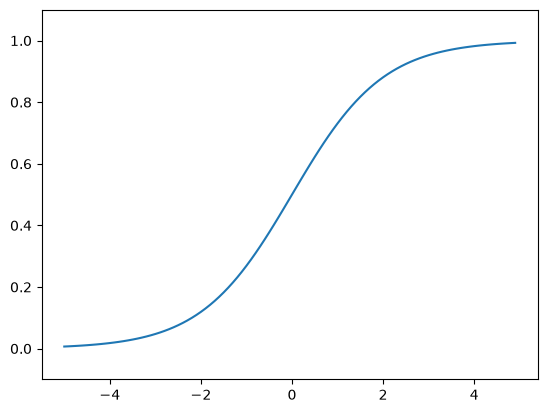

In [ ]:
# 그래프 그려보기
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

#### Tanh 함수(하이퍼볼릭 탄젠트 함수)

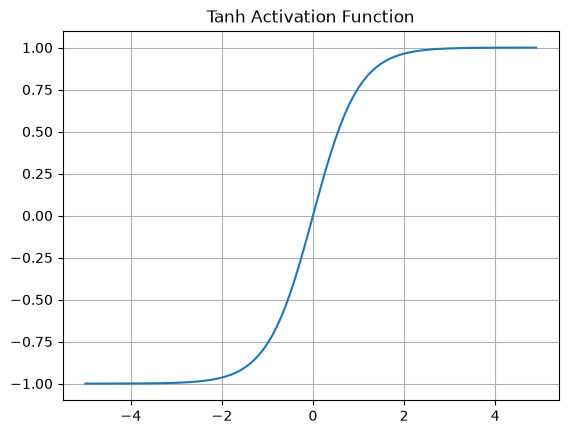

In [5]:
import numpy as np
import matplotlib.pylab as plt

def tanh(x):
    return np.tanh(x)

# 그래프 그리기
x = np.arange(-5.0, 5.0, 0.1)
y = tanh(x)

plt.plot(x, y)
plt.ylim(-1.1, 1.1)     # y축 범위 설정 : 0.1은 그래프에 여백을 주기 위한 것. 중요치 않음
plt.title("Tanh Activation Function")
plt.grid()
plt.show()

#### ReLU 함수

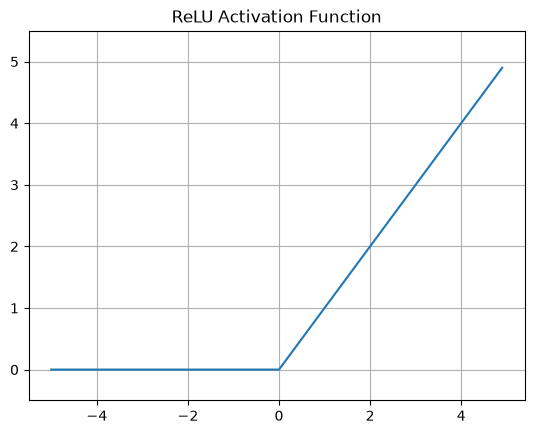

In [7]:
import numpy as np
import matplotlib.pylab as plt

def relu(x):
    return np.maximum(0, x)

# 그래프 그리기
x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.ylim(-0.5, 5.5)     # y축 범위 설정
plt.title("ReLU Activation Function")
plt.grid()
plt.show()

### 텐서플로우(tensorflow)

#### TensorFlow를 활용한 y = 2x + 1 선형회귀 모델 예측 예제

In [12]:
import sys

print(sys.executable)

d:\pythonscript\.venv\Scripts\python.exe


In [13]:
import sys

!{sys.executable} -m pip show tensorflow

Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: d:\pythonscript\.venv\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, termcolor, typing_extensions, wrapt
Required-by: 


In [ ]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [1]:
### TensorFlow를 활용한 y = 2x + 1 선형회귀 모델 예측 예제 ###
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# # 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# # 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False


In [16]:
# 1. 데이터 준비
# x_data: 입력 데이터, y_data: 실제 값 (정답)
x_data = np.array([0, 1, 2, 3, 4], dtype=np.float32)
y_data = np.array([1, 3, 5, 7, 9], dtype=np.float32)

In [4]:
# 2. 모델 정의
# 가중치(w)와 편향(b)를 변수로 정의
w = tf.Variable(0.0)  # 초기 가중치
b = tf.Variable(0.0)  # 초기 편향

In [5]:
# 예측 함수 (y = wx + b)
def predict(x):
    return w * x + b

In [6]:
# 3. 손실 함수 정의
# 평균 제곱 오차 (Mean Squared Error, MSE) 사용
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))  # reduce_mean : 제곱한 오차들의 평균

In [7]:
# 4. 최적화 알고리즘 선택
optimizer = tf.optimizers.SGD(learning_rate=0.01)  # 확률적 경사 하강법

In [10]:
# 5. 학습 과정
for step in range(100):  # 100번 반복
    with tf.GradientTape() as tape:
        y_pred = predict(x_data)  # 예측값
        loss = loss_fn(y_data, y_pred)  # 손실 계산

    # 가중치와 편향에 대한 경사도 계산 및 업데이트
    gradients = tape.gradient(loss, [w, b])    # 가중치, 절편에 대해 미분 계산
    optimizer.apply_gradients(zip(gradients, [w, b])) # optimizer(예: SGD, Adam 등)가 기울기를 이용해서 w,b를 업데이트

    if step % 10 == 0:  # 10번마다 로그 출력
        print(f"Step {step}, Loss: {loss.numpy()}, w: {w.numpy()}, b: {b.numpy()}")

Step 0, Loss: 33.0, w: 0.2800000011920929, b: 0.09999999403953552
Step 10, Loss: 1.8755830526351929, w: 1.6574040651321411, b: 0.6004058718681335
Step 20, Loss: 0.1229294165968895, w: 1.9802603721618652, b: 0.7298945188522339
Step 30, Loss: 0.02239181473851204, w: 2.053251266479492, b: 0.7707916498184204
Step 40, Loss: 0.014991003088653088, w: 2.0671944618225098, b: 0.7900874018669128
Step 50, Loss: 0.013025244697928429, w: 2.0673303604125977, b: 0.8037028312683105
Step 60, Loss: 0.011540031060576439, w: 2.06437611579895, b: 0.8154456615447998
Step 70, Loss: 0.010236968286335468, w: 2.0608623027801514, b: 0.8262498378753662
Step 80, Loss: 0.009081726893782616, w: 2.0573794841766357, b: 0.8363654017448425
Step 90, Loss: 0.00805690512061119, w: 2.0540578365325928, b: 0.8458786010742188


In [11]:
# 6. 예측 및 결과 확인
print("Final Parameters:", f"w={w.numpy()}, b={b.numpy()}")
print("Prediction for x=5:", predict(5).numpy())

Final Parameters: w=2.051225423812866, b=0.8539638519287109
Prediction for x=5: 11.110091


#### keras를 활용한 y = 2x + 1 선형회귀 모델 예측 예제

In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
# 데이터 준비
# 입력(x)과 출력(y) 데이터 정의
x_data = np.array([0, 1, 2, 3, 4], dtype=np.float32)    # 입력 데이터
y_data = np.array([1, 3, 5, 7, 9], dtype=np.float32)    # 정답 데이터

In [5]:
# 모델 정의
# Sequential API를 사용해 신경망을 정의
model = Sequential([
    Dense(1, input_dim=1)   # 입력 1개, 출력 1개 (선형 회귀)
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 모델 컴파일
# 손실 함수와 옵티마이저를 설정
model.compile(optimizer='sgd', loss='mse')

In [7]:
# 모델 학습
# fit() 메서드로 데이터 학습
model.fit(x_data, y_data, epochs=50, verbose=1)     # 50번 반복 학습

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 79.7733
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 59.8237
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 44.8635
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 33.6448
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 25.2319
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 18.9230
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 14.1919
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 10.6440
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7.9834
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 5.9883
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 4.4921
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 3.3700
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 2.5286
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.8976
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.4244
Epoch 16/50
1/1 ━━━━━━━━━━

In [8]:
# 예측 및 평가
# 새로운 데이터로 예측 수행
x_new = np.array([5], dtype=np.float32)
y_new = model.predict(x_new)

print(f"x = 5일 때, 예측된 y = {y_new[0][0]: .2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
x = 5일 때, 예측된 y =  10.91


#### MINST 예제 (CNN모델 예제)

In [12]:
# 필요한 라이브러리 임포트
import tensorflow as tf     # 딥러닝 라이브러리
from tensorflow.keras import layers, models     # 신경망 계층 및 모델 설계
from tensorflow.keras.datasets import mnist     # MNIST 데이터셋
import matplotlib.pyplot as plt                 # 시각화 도구

In [13]:
# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

In [35]:
# 데이터 로드 및 전처리
# MNIST 데이터셋은 이미 나뉘어 제공(학습/테스트 데이터)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [36]:
print(x_train.shape)
print(x_test.shape)

# 갯수, 이미지 높이, 이미지 너비

(60000, 28, 28)
(10000, 28, 28)


In [37]:
# MNIST 이미지는 28x28 크기, 채널 정보 추가(흑백 이미지는 채널 1개, 컬러는 3개)
# 0~1로 정규화, 픽셀은 0에서 255까지 값을 가짐
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255.0

In [ ]:
# 레이블을 원핫인코딩 (숫자 0~9를 벡터로 변환) ex) 0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
if len(y_train.shape) == 1:     # shape이 (n, )인지 확인
    # to_categorical(원핫인코딩 대상, 클래스 갯수)
    y_train = tf.keras.utils.to_categorical(y_train, 10)
if len(y_test.shape) == 1:
    y_test = tf.keras.utils.to_categorical(y_test, 10)

In [39]:
# CNN 모델 정의
model = models.Sequential()       # 순차적 모델 선언

In [40]:
# 첫 번째 합성곱 계층 : 필터 크기 3x3, 필터 수 32, 활성화 함수 ReLU
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

#풀링 계층 : 2x2 크기로 다운샘플링
model.add(layers.MaxPool2D((2,2)))

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
# 두 번째 합성곱 계층 : 필터 수 64
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPool2D((2, 2)))

In [42]:
# 세 번쨰 합성곱 계층 : 필터 수 128
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

In [43]:
# Fully Connected Layer를 연결하기 위해 Flatten 처리
model.add(layers.Flatten())

In [44]:
# Fully Connection Layer 1 : 뉴런 수 64, 활성화 함수 ReLU
model.add(layers.Dense(64, activation='relu'))

In [45]:
# 출력층 : 뉴런 수 10(클래스 수), 활성화 함수 softmax
model.add(layers.Dense(10, activation='softmax'))

In [47]:
# 모델 요약 출력(구조 확인용)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# 모델 컴파일

model.compile(optimizer='adam', 
              # 최적화 알고리즘 (손실값을 최소화하면서 모델이 최적의 가중치를 찾도록 안내하는 역할) 
              loss='categorical_crossentropy',    
              # 다중 클래스 분류, to_categorical 원핫인코딩 전처리 필요   
              # cf. 이진분류 : loss='binary_crossentropy'
              metrics = ['accuracy'])   # 평가 지표: 정확도

In [50]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9411 - loss: 0.1944 - val_accuracy: 0.9826 - val_loss: 0.0574
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9837 - loss: 0.0510 - val_accuracy: 0.9868 - val_loss: 0.0435
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.9896 - loss: 0.0332 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9914 - loss: 0.0262 - val_accuracy: 0.9884 - val_loss: 0.0408
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9925 - loss: 0.0237 - val_accuracy: 0.9875 - val_loss: 0.0463


In [51]:
# 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"테스트 정확도: {test_acc: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9892 - loss: 0.0351
테스트 정확도:  0.9892


In [52]:
# 결과 확인 : 테스트 데이터에서 임의의 이미지 예측
import numpy as np

# 테스트 데이터에서 첫 번째 샘플을 가져옴
sample_image = x_test[0]    # 첫번 째 이미지 저장
sample_label = np.argmax(y_test[0])
# y_test[0] 배열에서 가장 큰 값을 가지는 요소의 인덱스를 찾아 sample_label 변수에 저장
 # 참고 : y_test[0] = [0.01, 0.02, 0.05, 0.88, 0.01, 0.01, 0.01, 0.00, 0.01, 0.00]일 때 np.argmax(y_test[0])는 3을 반환

In [53]:
# 모델로 예측 수행
predicted_label = np.argmax(model.predict(sample_image.reshape(1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


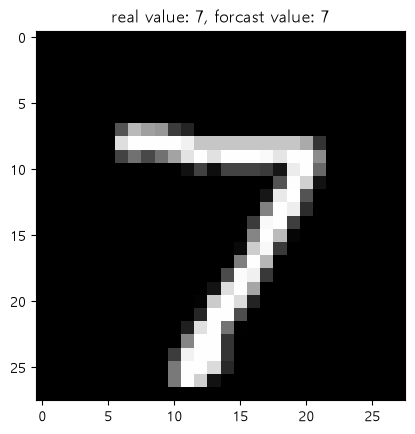

In [54]:
# 결과 출력
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"real value: {sample_label}, forcast value: {predicted_label}")
plt.show()

#### 꽃 이미지 분류 및 예측 예제(CNN)

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import os
import pathlib      # 객체지향 방식으로 파일 경로를 다룸
import urllib       # url을 통해 파일 다운로드 기능 제공
import tarfile

In [65]:
# 데이터 다운로드 함수
def download_and_extract_data():
    # 데이터 URL
    dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

    # 다운로드 할 디렉토리 생성
    ## 현재 폴더의 상위 경로
    parent_dir = os.path.dirname(os.getcwd())
    ## 상위 경로의 dataset/flower_dataset에 저장
    download_dir = os.path.join(parent_dir, "dataset", 'flower_dataset')
    os.makedirs(download_dir, exist_ok=True)
        
    # 파일 다운로드
    tgz_path = os.path.join(download_dir, "flower_photos.tgz")
    
    if not os.path.exists(tgz_path):
        print("데이터셋 다운로드 중...")
        # 지정된 URL에서 파일을 직접 다운로드하여 로컬에 저장
        urllib.request.urlretrieve(dataset_url, tgz_path)
        print("다운로드 완료!")
        
    # 압축 해제
    if not os.path.exists(os.path.join(download_dir, "flower_photos")):
        print("압축 해제 중...")
        with tarfile.open(tgz_path) as tar:
            tar.extractall(path=download_dir)
        print("압축 해제 완료!")
        
    return os.path.join(download_dir, "flower_photos")


In [66]:
## 데이터 다운로드 및 경로 설정

# 함수 호출
data_dir = download_and_extract_data()  
# 현재작업경로/flower_dataset/flower_photos)을 data_dir 변수에 저장
data_dir = pathlib.Path(data_dir)

print(data_dir)

데이터셋 다운로드 중...
다운로드 완료!
압축 해제 중...


C:\Users\human-10\AppData\Local\Temp\ipykernel_9252\2576924367.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=download_dir)


압축 해제 완료!
d:\pythonscript\dataset\flower_dataset\flower_photos


In [68]:
# 클래스 및 이미지 개수 확인
# data_dir.glib('*/'): data_dir(pathlib.Path 객체) 아래의 모든 하위 디렉토리를 탐색
# item.is_dir() : 탐색된 항목이 실제로 디랙토리인지 확인하는 조건

# 리스트 컴프리헨션을 사용하여 각 디렉터리의 이름(예: 'daisy', 'dandelion' 등)만 추출
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()])
image_count = len(list(data_dir.glob('*/*.jpg')))

print(f"발견된 클래스: {classes}")
print(f"총 이미지 개수: {image_count}")

발견된 클래스: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
총 이미지 개수: 3670


In [69]:
# 각 클래스별 이미지 개수 확인
for class_name in classes:
    class_images = len(list(data_dir.glob(f'{class_name}/*')))
    print(f"{class_name}: {class_images}개 이미지")

daisy: 633개 이미지
dandelion: 898개 이미지
roses: 641개 이미지
sunflowers: 699개 이미지
tulips: 799개 이미지


In [71]:
# 이미지 크기 및 배치 크기 설정
img_height = 180
img_width = 180
batch_size = 32

In [79]:
# 훈련 데이터셋 생성(cf. image_dataset_from_directory : 자동으로 폴더 기준 라벨 부여)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split = 0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [80]:
# 검증 데이터셋 생성
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split = 0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [81]:
# 클래스 이름 확인

# class_names: 하위 폴더 이름들을 클래스 이름으로 인식
class_names = train_ds.class_names
print("클래스:", class_names)
num_classes = len(class_names)

클래스: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [82]:
# 데이터셋 성능 최적화

# 시스템 자원(CPU, GPU, 메모리 등)을 분석하여 
# 최적의 버퍼 크기나 병렬 처리 수를 자동으로 결정
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [83]:
# 데이터 증강 레이어 정의
data_augumentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),     # 360도의 20% = 72도 회전
    layers.RandomZoom(0.2)
])

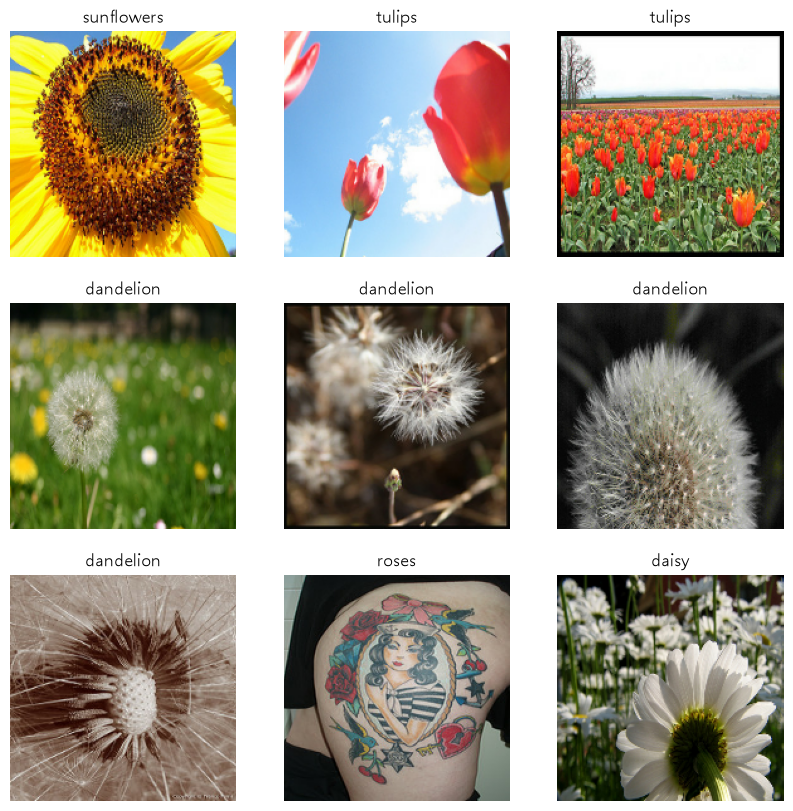

In [85]:
# 샘플 이미지 시각화
plt.figure(figsize=(10, 10))

# 데이터셋에서 첫 번째 배치 하나만 가져옴
for images, labels in train_ds.take(1):     
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # astype("uint8"): 픽셀값을 0~255 정수로 변환
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [86]:
# CNN 모델 구성
model = tf.keras.Sequential([
    data_augumentation,
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    # 언급이 없을 경우에는 (2,2)가 디폴트로 사용됨, (2,2): 풀링할 영역의 크기
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2), 
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [88]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    # 다중클래스에서 주로 사용, 
    # 예: 레이블이 0, 1, 2... 인 정수 인코딩된 인덱스(전처리 불필요)
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [89]:
# Early Stopping 콜백 설정
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True  # 가장 좋았던 val_loss 가중치로 복원
    )
]

In [90]:
# 모델 학습
epochs = 15
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = epochs,
    callbacks = callbacks
)

Epoch 1/15


d:\pythonscript\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 297ms/step - accuracy: 0.4288 - loss: 1.3620 - val_accuracy: 0.5504 - val_loss: 1.0992
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 274ms/step - accuracy: 0.5743 - loss: 1.0885 - val_accuracy: 0.5790 - val_loss: 1.0562
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 277ms/step - accuracy: 0.6107 - loss: 0.9849 - val_accuracy: 0.6117 - val_loss: 0.9664
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.6400 - loss: 0.9288 - val_accuracy: 0.6376 - val_loss: 0.9304
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 270ms/step - accuracy: 0.6703 - loss: 0.8699 - val_accuracy: 0.6376 - val_loss: 1.0134
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 253ms/step - accuracy: 0.6764 - loss: 0.8292 - val_accuracy: 0.6703 - val_loss: 0.8303
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 281ms/step - accuracy: 0.6887 - loss: 0.8018 - val_accuracy: 0.6921 - val_loss: 0.8523
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 272ms/step - accuracy: 0.7112 - loss: 0.7540 - val_accuracy: 0.708

In [91]:
# 모델 구조 출력
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,967,857 (45.65 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,978,572 (30.44 MB)

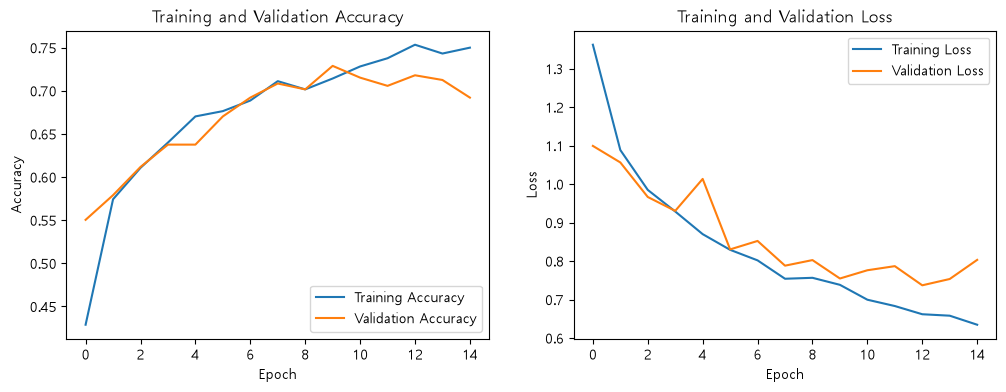

In [94]:
# 학습 결과 시각화
acc = history.history['accuracy']   # 뒤의 history는 학습 과정을 담고 있는 딕셔너리
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [95]:
# 모델 저장
model.save('../model/flower_classfication_model.h5')    # 저장된 모델 경로
print("모델이 저장되었습니다.")

모델이 저장되었습니다.


In [96]:
# 저장된 모델 불러오기
from tensorflow.keras.models import load_model

model_path = '../model/flower_classfication_model.h5'
loaded_model = load_model(model_path)
print("모델이 성공적으로 로드되었습니다.")

모델이 성공적으로 로드되었습니다.


In [97]:
# 저장된 모델을 활용한 이미지 예측 함수
def predict_flower_with_loaded_model(img_path, model, class_names):
    """
    이미지 경로와 모델을 입력받아 예측 결과를 출력하고 이미지를 시각화하는 함수.

    Parameters:
        img_path (str): 예측할 이미지 파일 경로.
        model (tf.keras.Model): 저장된 모델.
        class_names (list): 클래스 이름 리스트.
    """
    
    # 이미지 로드 및 전처리
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(img_height, img_width)       # PIL 이미지 객체
    )
    
    # 이미지를 숫자 배열(numpy 형태)로 변환
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # 배치 차원 추가 : ex. (1, 높이, 너비, 3) 형태의 배치
    # 0은 가장 앞쪽(0번째 위치) 에 새로운 차원을 추가
    img_array = tf.expand_dims(img_array, 0)
    
    # 예측 수행
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    
    # 예측 결과 출력
    print("이 이미지는 '{} ({: .2f}% 확률) 입니다."
          .format(class_names[np.argmax(score)], 100 * np.max(score))
    )
    
    # 이미지 시각화
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [109]:
# 테스트 이미지 경로
#test_image_path = './flower_dataset/flower_photos/daisy/5547758_eea9edfd54_n.jpg'

test_image_path = '../dataset/flower_dataset/flower_photos/roses/12240303_80d87f77a3_n.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
이 이미지는 'roses ( 29.38% 확률) 입니다.


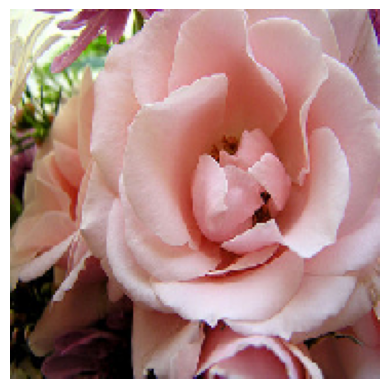

In [110]:
# 예측 실행
predict_flower_with_loaded_model(test_image_path, loaded_model, class_names)

#### 이미지 예측(YOLO 모델)

In [1]:
import cv2                      # OpenCV로 이미지 처리(예: 색상 변환, 바운딩 박스 그리기)
import matplotlib.pyplot as plt
from ultralytics import YOLO    # YOLOv8 모델을 로드하고 예측에 사용
import requests                 # 인터넷에서 이미지를 다운로드
from io import BytesIO          # 다운로드한 이미지 데이터를 바이트(이진)코드로 저장 후 메모리에서 처리
from PIL import Image
import numpy as np

In [2]:
# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

In [3]:
# YOLOv8 모델 로드
# yolov8n.pt : 가장 가벼운 모델 -> CPU 환경에 적합
model = YOLO('yolov8n.pt')

In [4]:
# 테스트 이미지 URL
image_url = "https://image.lawtimes.co.kr/images/202707.jpg" # 강아지 샘플

# URL에서 이미지 다운로드
try:
    response = requests.get(image_url)       # 이미지 데이터 다운로드
    image_data = BytesIO(response.content)  # 바이트코드를 파일처럼 사용
    # PIL(Pillow)로 이미지 열기
    image_pil = Image.open(image_data)
    # numpy array로 변환 (OpenCV 형식)
    image_np = np.array(image_pil)
    # OpenCV는 BGR 형식을 사용하므로 RGB에서 BGR로 변환
    image_cv = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
    
    # 이미지 크기 확인 : 높이, 너비, 채널 수
    print(f"이미지 크기: {image_cv.shape}")
    
except Exception as e:
    print(f"이미지 다운로드 또는 변환 중 오류 발행: {e}")
    exit()

이미지 크기: (400, 600, 3)


In [6]:
# 원본 이미지 복사 : 시각화 작업을 위해. 원본 보존
image_for_display = image_cv.copy()

# 모델 예측 실행
results = model.predict(source=image_cv, save=False, verbose=False)

# 탐지된 객체 정보 저장
best_object = None

# 탐지 결과에서 'cat' 또는 'dog' 중 가장 높은 신뢰도의 객체 찾기
if results and results[0].boxes:
    for result in results:
        # boxes.xyxy: 바운딩 박스 좌표(왼쪽 상단: x1, y1, 오른쪽 하단: x2, y2)
        boxes = result.boxes.xyxy.cpu().numpy()
        # 탐지된 객체의 클래스 ID(예: 15는 고양이, 16은 강아지)
        classes = result.boxes.cls.cpu().numpy()
        # 탐지 신뢰도(0~1 사이 값)
        confidences = result.boxes.conf.cpu().numpy()
        # 클래스 ID에 대응하는 이름(예: 15: 'cat', 16: 'dog')
        class_names = result.names
        
        for box, cls, conf in zip(boxes, classes, confidences):
            class_name = class_names[int(cls)]
            
            # 'cat'과 'dog'만 필터링
            if class_name in ['cat', 'dog']:
                if best_object is None or conf > best_object['confidence']:
                    best_object = {
                        'class_name': class_name,
                        'confidence': conf,
                        'box': box
                    }
    
    # 탐지된 객체 시각화
    best_guess = "탐지된 객체 없음"
    
    if best_object:
        class_name = best_object['class_name']
        confidence = best_object['confidence']
        box = best_object['box']
        
        # 최고 신뢰도 객체 정보 출력
        # YOLO 모델은 좌표를 float 형태로 주기 때문에, OpenCV 함수에서는 정수변환
        x1, y1, x2, y2 = [int(v) for v in box]
        print(f"\n === 최고 신뢰도 탐지 결과 ===")
        print(f"클래스: {class_name}, 신뢰도: {confidence: .2f}, 좌표: ({x1}, {y1}, {x2}, {y2})")
        
        # 라벨 그리기
        label = f"{class_name}: {confidence: .2f}"
        
        # 바운딩 박스 그리기 : 녹색(0, 255, 0), 두께(2) 사각형
        cv2.rectangle(image_for_display, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # 텍스트 라벨과 배경 박스 그리기
        (w, h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
        # 라벨 배경 사각형, -1: 사각형을 채움
        cv2.rectangle(image_for_display, (x1, y1 - h - baseline), (x1 + w, y1), (0, 255, 0), -1)
        cv2.putText(image_for_display, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)
        
        best_guess = class_name


 === 최고 신뢰도 탐지 결과 ===
클래스: dog, 신뢰도:  0.68, 좌표: (252, 64, 598, 239)


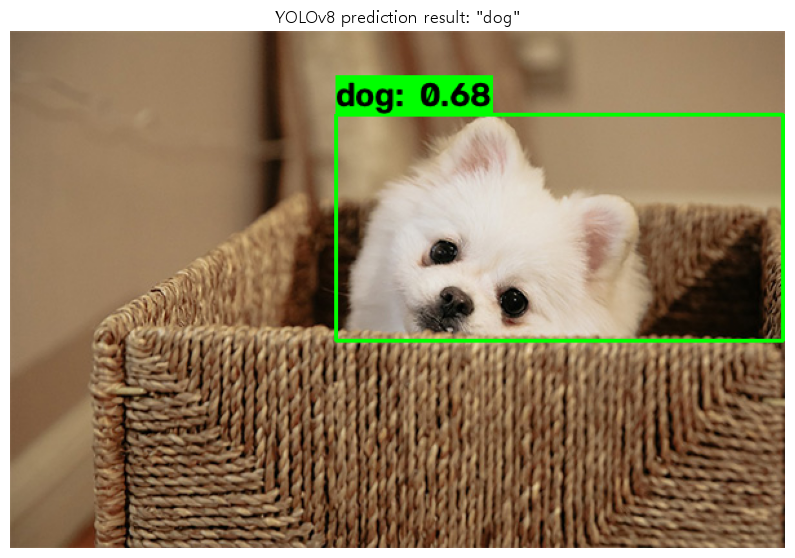

In [8]:
# 결과 이미지를 BGR에서 RGB로 변환하여 Matplotlib로 출력
image_result_rgb = cv2.cvtColor(image_for_display, cv2.COLOR_BGR2RGB)

# 이미지 출력
plt.figure(figsize=(10, 8))
plt.imshow(image_result_rgb)
plt.axis('off')
plt.title(f'YOLOv8 prediction result: "{best_guess}"')
plt.show()